In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score

from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

In [8]:
# 1. Load + Clean Data

df = pd.read_csv("adult.csv")
df.columns = df.columns.str.strip()

df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

df["income"] = df["income"].astype(str).str.strip().str.replace(".", "", regex=False)
df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

# Sensitive attribute
df["race"] = df["race"].str.strip()
sensitive_feature = df["race"]

rare_threshold = 1000
race_counts = df["race"].value_counts()

df["race_grouped"] = df["race"].apply(
    lambda x: x if race_counts[x] >= rare_threshold else "Other"
)

sensitive_feature = df["race_grouped"]

print("Dataset shape:", df.shape)

Dataset shape: (30162, 16)


In [9]:
# 2. Basic Distribution Checks

print("\n=== TARGET DISTRIBUTION ===")
print(df["income"].value_counts(normalize=True))

print("\n=== SENSITIVE ATTRIBUTE DISTRIBUTION (RACE) ===")
print(sensitive_feature.value_counts(normalize=True))

print("\n=== GROUP vs TARGET (RACE) ===")
print(pd.crosstab(sensitive_feature, df["income"], normalize='index'))


=== TARGET DISTRIBUTION ===
income
0    0.751078
1    0.248922
Name: proportion, dtype: float64

=== SENSITIVE ATTRIBUTE DISTRIBUTION (RACE) ===
race_grouped
White    0.859790
Black    0.093396
Other    0.046814
Name: proportion, dtype: float64

=== GROUP vs TARGET (RACE) ===
income               0         1
race_grouped                    
Black         0.870075  0.129925
Other         0.785411  0.214589
White         0.736282  0.263718


In [10]:
# 3. Feature Engineering

X = df.drop(columns=["income", "race"])
y = df["income"]

categorical_cols = X.select_dtypes(include=["object", "string"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X_encoded, y, sensitive_feature,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nTrain shape:", X_train_scaled.shape)


Train shape: (24129, 94)


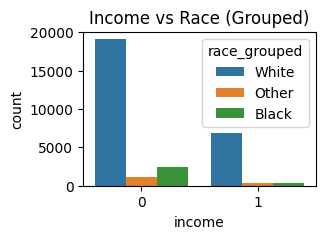

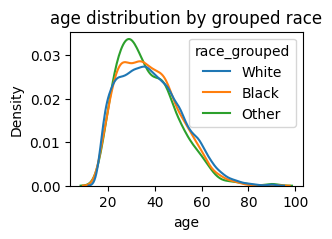

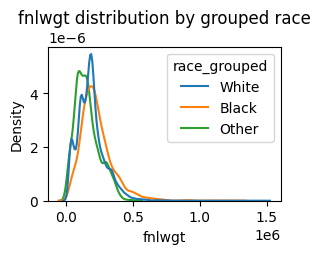

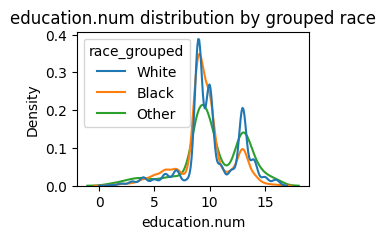

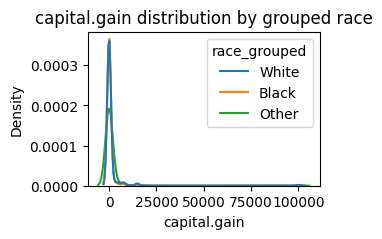

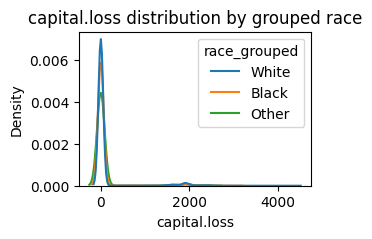

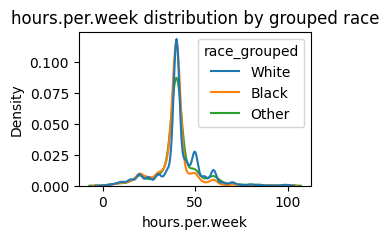

In [12]:
# Income vs Race (grouped)

plt.figure(figsize=(3, 2))
sns.countplot(x=df["income"], hue=df["race_grouped"])
plt.title("Income vs Race (Grouped)")
plt.show()


# Numeric Feature Distributions by Group (grouped race)

for col in numeric_cols:
    plt.figure(figsize=(3, 2))  
    sns.kdeplot(data=df, x=col, hue="race_grouped", common_norm=False)
    plt.title(f"{col} distribution by grouped race")
    plt.show()

In [15]:
print("\n=== PROXY FEATURE CORRELATION WITH RACE (one-vs-rest) ===")

corrs = {}

for group in sensitive_feature.unique():
    
    group_binary = (sensitive_feature == group).astype(int)
    
    for col in X_encoded.columns:
        corr = np.corrcoef(X_encoded[col], group_binary)[0,1]
        corrs[(col, group)] = abs(corr)

corr_series = pd.Series(corrs).sort_values(ascending=False)

corr_df = corr_series.reset_index()
corr_df.columns = ["feature", "race", "correlation"]

print(corr_df.head(20))

# print(corr_series.head(20))


=== PROXY FEATURE CORRELATION WITH RACE (one-vs-rest) ===
                              feature   race  correlation
0                  race_grouped_Other  Other     1.000000
1                  race_grouped_White  White     1.000000
2                  race_grouped_White  Black     0.794808
3                  race_grouped_White  Other     0.548790
4                  race_grouped_Other  White     0.548790
5        native.country_United-States  Other     0.349125
6          native.country_Philippines  Other     0.339414
7                native.country_India  Other     0.232948
8                native.country_South  Other     0.215947
9                native.country_China  Other     0.207876
10             native.country_Vietnam  Other     0.201255
11       native.country_United-States  White     0.192115
12         native.country_Philippines  White     0.186410
13              native.country_Taiwan  Other     0.160082
14             relationship_Unmarried  Black     0.147753
15           

In [16]:
# 6. Baseline Model (Sanity Check)
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

f1 = f1_score(y_test, y_pred)

print("\n=== BASELINE PERFORMANCE ===")
print("F1:", f1)


=== BASELINE PERFORMANCE ===
F1: 0.6819672131147541


In [17]:
# 7. Baseline Fairness
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=s_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=s_test)

dp = 1 - abs(dp_diff)
eo = 1 - abs(eo_diff)

print("\n=== BASELINE FAIRNESS ===")
print("DP (fairness score):", dp)
print("EO (fairness score):", eo)


=== BASELINE FAIRNESS ===
DP (fairness score): 0.8891936998162377
EO (fairness score): 0.9062778987965575


In [18]:
print("\n=== GROUP-WISE METRICS (RACE) ===")

for group in np.unique(s_test):
    idx = (s_test == group)
    
    print(f"\nGroup: {group}")
    print("F1:", f1_score(y_test[idx], y_pred[idx]))
    print("Samples:", np.sum(idx))


=== GROUP-WISE METRICS (RACE) ===

Group: Black
F1: 0.6197183098591549
Samples: 556

Group: Other
F1: 0.6262626262626263
Samples: 274

Group: White
F1: 0.6876996805111821
Samples: 5203


In [10]:
# 9. Baseline Fairness (Dummy Model)

y_dummy = np.zeros_like(y_test)

dp_dummy = demographic_parity_difference(y_test, y_dummy, sensitive_features=s_test)
eo_dummy = equalized_odds_difference(y_test, y_dummy, sensitive_features=s_test)

print("\n=== DUMMY MODEL FAIRNESS ===")
print("DP diff:", dp_dummy)
print("EO diff:", eo_dummy)


=== DUMMY MODEL FAIRNESS ===
DP diff: 0.0
EO diff: 0.0


In [20]:
# Define a simple individual fairness metric
from sklearn.metrics.pairwise import euclidean_distances

def individual_fairness_score(X, y_pred, sample_size=1000):
    np.random.seed(42)

    idx = np.random.choice(len(X), size=min(sample_size, len(X)), replace=False)
    
    X_sample = X.iloc[idx].values
    y_sample = y_pred[idx]

    dists = euclidean_distances(X_sample)

    # remove self-comparisons
    np.fill_diagonal(dists, np.inf)

    # stricter similarity
    threshold = np.percentile(dists, 5)
    similar = dists < threshold

    pred_diff = np.abs(y_sample[:, None] - y_sample[None, :])

    score = 1 - np.mean(pred_diff[similar])

    return score

distance_cols = ["age", "education.num", "hours.per.week"]

X_dist = X_test_scaled[distance_cols]

if_score = individual_fairness_score(X_dist, y_pred)

print("\n=== BASELINE INDIVIDUAL FAIRNESS ===")
print("IF score:", if_score)


=== BASELINE INDIVIDUAL FAIRNESS ===
IF score: 0.8267545622638476


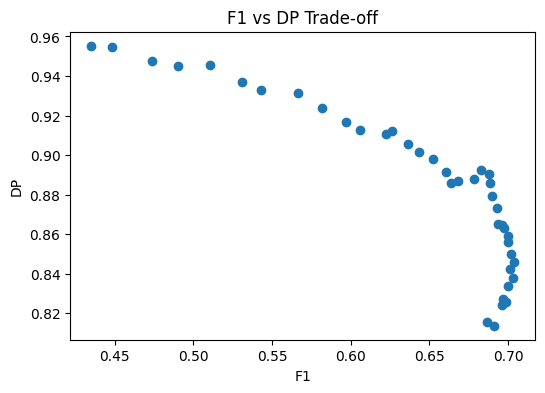

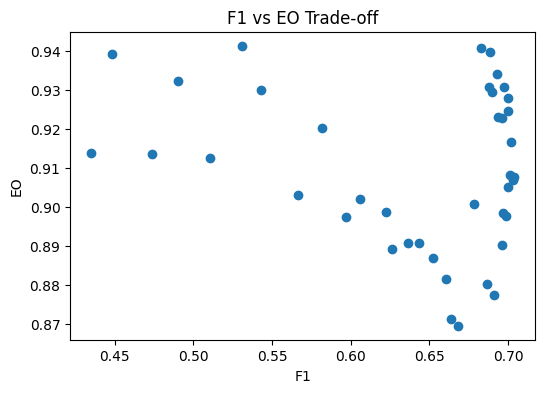

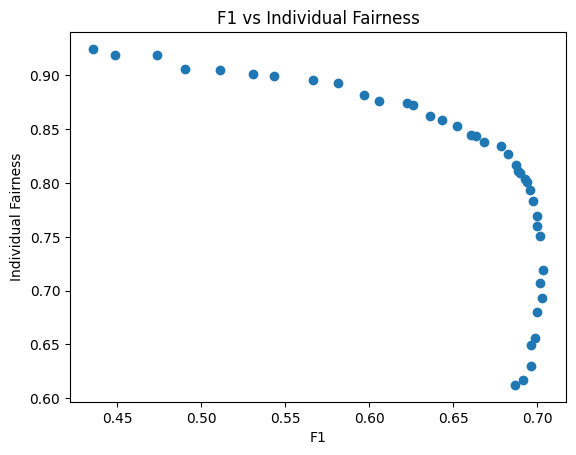

In [21]:
# 10. Threshold Trade-off Analysis (KEY STEP)

probs = model.predict_proba(X_test_scaled)[:,1]

thresholds = np.linspace(0.2, 0.8, 40)

results = []

for t in thresholds:
    y_pred_t = (probs >= t).astype(int)

    f1 = f1_score(y_test, y_pred_t)
    dp = 1 - abs(demographic_parity_difference(y_test, y_pred_t, sensitive_features=s_test))
    eo = 1 - abs(equalized_odds_difference(y_test, y_pred_t, sensitive_features=s_test))
    if_score = individual_fairness_score(X_dist, y_pred_t)

    results.append((f1, dp, eo, if_score))

results = np.array(results)

plt.figure(figsize=(6, 4))
plt.scatter(results[:,0], results[:,1])
plt.xlabel("F1")
plt.ylabel("DP")
plt.title("F1 vs DP Trade-off")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(results[:,0], results[:,2])
plt.xlabel("F1")
plt.ylabel("EO")
plt.title("F1 vs EO Trade-off")
plt.show()

plt.figure()
plt.scatter(results[:,0], results[:,3])
plt.xlabel("F1")
plt.ylabel("Individual Fairness")
plt.title("F1 vs Individual Fairness")
plt.show()

In [22]:
# 11. Objective Correlation Check (CRITICAL)

# print("\n=== OBJECTIVE CORRELATION ===")
# print(np.corrcoef(results.T))

print("\n=== OBJECTIVE CORRELATION (WITH IF) ===")
print(np.corrcoef(results.T))


=== OBJECTIVE CORRELATION (WITH IF) ===
[[ 1.         -0.86980507 -0.21280868 -0.734017  ]
 [-0.86980507  1.          0.28342953  0.96656705]
 [-0.21280868  0.28342953  1.          0.27064371]
 [-0.734017    0.96656705  0.27064371  1.        ]]


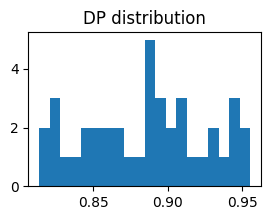

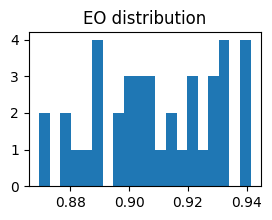

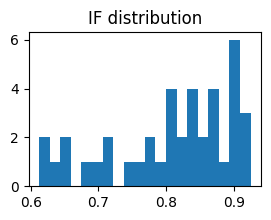

In [23]:
# 12. Metric Spread (Detect Flatness)

plt.figure(figsize=(3, 2))
plt.hist(results[:,1], bins=20)
plt.title("DP distribution")
plt.show()

plt.figure(figsize=(3, 2))
plt.hist(results[:,2], bins=20)
plt.title("EO distribution")
plt.show()

plt.figure(figsize=(3, 2))
plt.hist(results[:,3], bins=20)
plt.title("IF distribution")
plt.show()

In [24]:
# STEP 1 — Define Model Training (clean + controlled)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def train_model(model_type, reg, n_trees, depth, min_samples_leaf, class_weight_scale, X_tr, y_tr):

    if class_weight_scale > 1:
        class_weight = {0: 1.0, 1: class_weight_scale}
    else:
        class_weight = None

    if model_type == 0:
        model = LogisticRegression(
            C=1/reg,
            max_iter=300,
            class_weight=class_weight,
            solver="liblinear",
            random_state=42
        )
    else:
        model = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            min_samples_leaf=min_samples_leaf,
            class_weight=class_weight,
            n_jobs=-1,
            random_state=42
        )

    model.fit(X_tr, y_tr)
    return model

In [25]:
def predict_group_threshold(model, X, sensitive, thresholds_dict):

    probs = model.predict_proba(X)[:, 1]

    # map each sample to its group threshold
    thresholds = sensitive.map(thresholds_dict).values

    preds = (probs >= thresholds).astype(int)

    return preds

In [26]:
# STEP 3 — Metrics (UPDATED for final objectives)

from sklearn.metrics import f1_score
from fairlearn.metrics import demographic_parity_difference

def evaluate_metrics(y_true, y_pred, sensitive):

    f1 = f1_score(y_true, y_pred)

    dp = 1 - abs(
        demographic_parity_difference(
            y_true, y_pred, sensitive_features=sensitive
        )
    )

    return f1, dp

In [27]:
# STEP 4 — Complexity Metric (VERY IMPORTANT)

def model_complexity(model, model_type):

    ####### i was using this previously (let's call it "raw complexity" for now)
    # if model_type == 0:
    #     # Logistic Regression → number of coefficients
    #     return np.sum(np.abs(model.coef_))
    # else:
    #     # Random Forest → total number of nodes
    #     return sum(tree.tree_.node_count for tree in model.estimators_)
    
    if model_type == 0:
        return np.sum(np.abs(model.coef_))
    else:
        return np.log(sum(tree.tree_.node_count for tree in model.estimators_) + 1)

In [28]:
race_groups = sorted(s_train.unique())

In [29]:
# STEP 5 — CROSS-VALIDATED Evaluation (CRITICAL FIX)

from sklearn.model_selection import StratifiedKFold

def evaluate_solution(x):

    model_type = int(round(x[0]))
    reg = x[1]
    n_trees = int(x[2])
    depth = int(x[3])
    min_samples_leaf = int(x[4])
    class_weight_scale = x[5]
    # t_male = x[6]
    # t_female = x[7]

    # Clip thresholds
    thresholds = x[6:6+len(race_groups)]
    thresholds = np.clip(thresholds, 0.3, 0.7)

    thresholds_dict = dict(zip(race_groups, thresholds))

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    f1s, dps, comps = [], [], []

    for train_idx, val_idx in skf.split(X_train_scaled, y_train):

        X_tr = X_train_scaled.iloc[train_idx]
        X_val = X_train_scaled.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        s_tr = s_train.iloc[train_idx]
        s_val = s_train.iloc[val_idx]

        model = train_model(
            model_type, reg, n_trees, depth,
            min_samples_leaf, class_weight_scale,
            X_tr, y_tr
        )

        y_pred = predict_group_threshold(model, X_val, s_val, thresholds_dict)

        # reject degenerate predictions
        pos_rate = np.mean(y_pred)
        if pos_rate < 0.05 or pos_rate > 0.95:
            continue

        f1, dp = evaluate_metrics(y_val, y_pred, s_val)
        comp = model_complexity(model, model_type)

        f1s.append(f1)
        dps.append(dp)
        comps.append(comp)

    # fallback if all folds rejected
    if len(f1s) == 0:
        return 0.0, 0.0, 1e6

    return np.mean(f1s), np.mean(dps), np.mean(comps)

In [30]:
# STEP 6 — Define PyMOO Problem (FINAL FORM)

from pymoo.core.problem import Problem

class FairnessMOO(Problem):

    def __init__(self):
        n_groups = len(race_groups)

        super().__init__(
            n_var=6 + n_groups,
            n_obj=3,
            xl=np.array([0, 1e-4, 100, 5, 1, 0.5] + [0.3]*n_groups),
            xu=np.array([1, 10, 500, 25, 10, 3.0] + [0.7]*n_groups)
        )

    def _evaluate(self, X, out, *args, **kwargs):

        results = []

        for x in X:
            f1, dp, comp = evaluate_solution(x)

            # minimize all
            results.append([
                -f1,        # maximize F1
                -dp,        # maximize fairness
                comp        # minimize complexity
            ])

        out["F"] = np.array(results)

In [21]:
# # STEP 7 — Run NSGA-II (FIXED SETTINGS)

# # raw complexity

# from pymoo.algorithms.moo.nsga2 import NSGA2
# from pymoo.optimize import minimize

# algorithm = NSGA2(pop_size=40)

# res = minimize(
#     FairnessMOO(),
#     algorithm,
#     ('n_gen', 30),
#     seed=42,
#     verbose=True
# )

In [31]:
# STEP 7 — Run NSGA-II (FIXED SETTINGS)

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize


algorithm = NSGA2(pop_size=100)

res = minimize(
    FairnessMOO(),
    algorithm,
    ('n_gen', 80),
    seed=42,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     21 |             - |             -
     2 |      200 |     30 |  0.0497368391 |         ideal
     3 |      300 |     44 |  0.5106363708 |         nadir
     4 |      400 |     62 |  0.0163823909 |         ideal
     5 |      500 |     68 |  0.0169116522 |         ideal
     6 |      600 |     85 |  0.0219994667 |             f
     7 |      700 |    100 |  0.0094652838 |             f
     8 |      800 |     95 |  0.1940461542 |         nadir
     9 |      900 |    100 |  0.0027473935 |         ideal
    10 |     1000 |    100 |  0.5364248503 |         nadir
    11 |     1100 |    100 |  0.0060323073 |             f
    12 |     1200 |     90 |  0.0588779093 |         ideal
    13 |     1300 |    100 |  0.0217741859 |         ideal
    14 |     1400 |    100 |  0.0176720365 |         nadir
    15 |     1500 |    100 |  0.1053478207 |         nadir
    16 |     1600 |    100 |  0.0219057002 |         nad

In [32]:
# STEP 8 — Extract Results

F = res.F.copy()
F[:,0] *= -1  # F1
F[:,1] *= -1  # DP

X_res = res.X

f1, dp, comp = F[:,0], F[:,1], F[:,2]

In [33]:
# # raw complexity

# print("Distribution of solutions:")

# print("f1 min:", f1.min(), "f1 max:", f1.max())
# print("dp min:", dp.min(), "dp max:", dp.max())
# print("comp min:", comp.min(), "comp max:", comp.max())


In [34]:
print("Distribution of solutions:")

print("f1 min:", f1.min(), "f1 max:", f1.max())
print("dp min:", dp.min(), "dp max:", dp.max())
print("comp min:", comp.min(), "comp max:", comp.max())


Distribution of solutions:
f1 min: 0.32683533803401077 f1 max: 0.7132007776878989
dp min: 0.5815683498170455 dp max: 0.9997663769741145
comp min: 8.384115215114965 comp max: 13.222250550669246


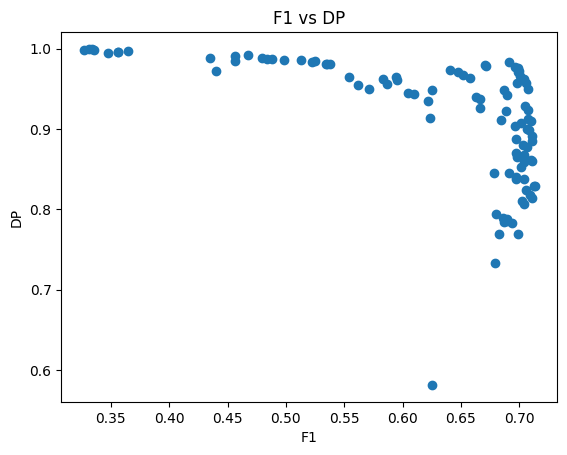

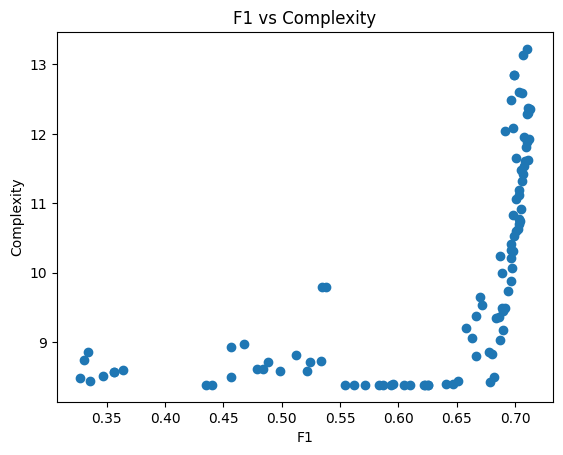

In [35]:
# STEP 9 — Plot Trade-offs

import matplotlib.pyplot as plt

plt.scatter(f1, dp)
plt.xlabel("F1")
plt.ylabel("DP")
plt.title("F1 vs DP")
plt.show()

plt.scatter(f1, comp)
plt.xlabel("F1")
plt.ylabel("Complexity")
plt.title("F1 vs Complexity")
plt.show()

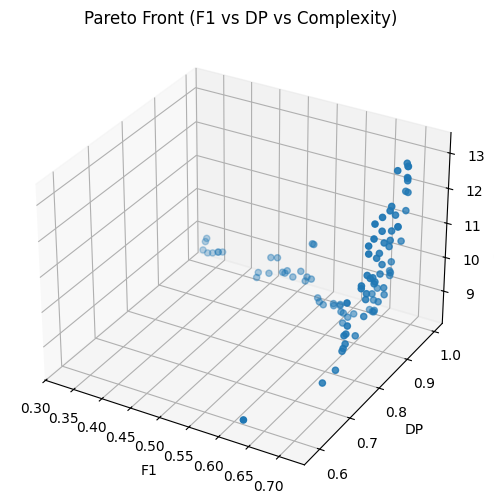

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(f1, dp, comp)

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

ax.set_title("Pareto Front (F1 vs DP vs Complexity)")

plt.show()

In [37]:
import numpy as np

# normalize objectives
f1_n = (f1 - f1.min()) / (f1.max() - f1.min())
dp_n = (dp - dp.min()) / (dp.max() - dp.min())
comp_n = (comp - comp.min()) / (comp.max() - comp.min())

# ideal = (max f1, max dp, min comp)
ideal = np.array([1, 1, 0])

points = np.vstack([f1_n, dp_n, comp_n]).T

# distance to ideal
dist = np.linalg.norm(points - ideal, axis=1)

best_idx = np.argmin(dist)

print("Best solution index:", best_idx)
print("F1:", f1[best_idx])
print("DP:", dp[best_idx])
print("Complexity:", comp[best_idx])

Best solution index: 40
F1: 0.6513842935157406
DP: 0.9669253576419866
Complexity: 8.436842469784738


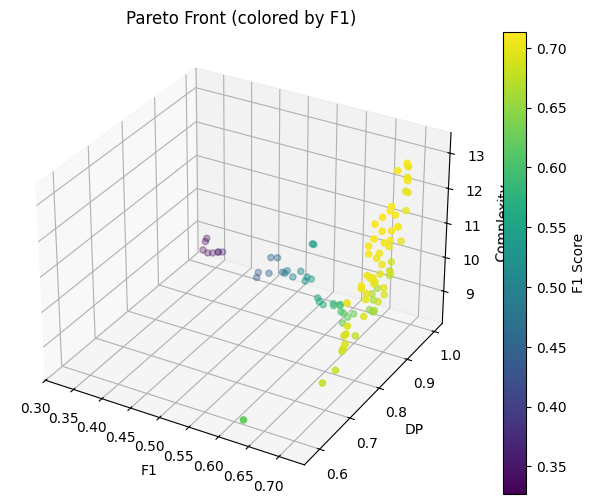

In [38]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')


sc = ax.scatter(f1, dp, comp, c=f1, cmap='viridis')

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

plt.colorbar(sc, label="F1 Score")

plt.title("Pareto Front (colored by F1)")

plt.show()

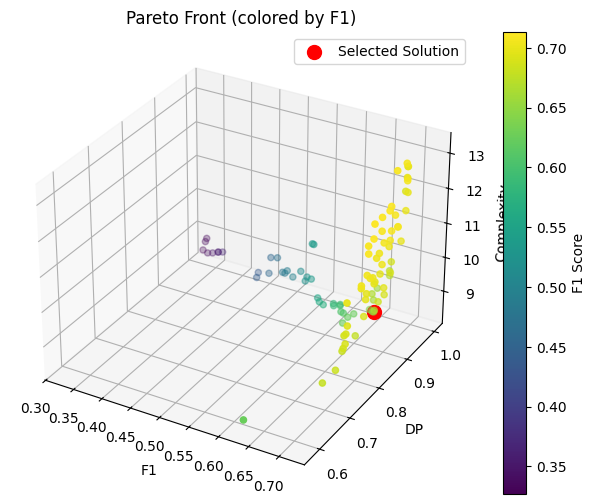

In [39]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    f1[best_idx],
    dp[best_idx],
    comp[best_idx],
    color='red',
    s=100,
    label='Selected Solution'
)

ax.legend()
sc = ax.scatter(f1, dp, comp, c=f1, cmap='viridis')

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

plt.colorbar(sc, label="F1 Score")

plt.title("Pareto Front (colored by F1)")

plt.show()

In [40]:
# STEP 1 — Normalize objectives (required)import numpy as np

f1_n = (f1 - f1.min()) / (f1.max() - f1.min())
dp_n = (dp - dp.min()) / (dp.max() - dp.min())
comp_n = (comp - comp.min()) / (comp.max() - comp.min())

In [41]:
# STEP 2 — Compute knee score (distance to ideal)
# Ideal point = max F1, max DP, min complexity → (1, 1, 0)

points = np.vstack([f1_n, dp_n, comp_n]).T
ideal = np.array([1, 1, 0])

dist = np.linalg.norm(points - ideal, axis=1)

In [42]:
# STEP 3 — Get top 3 candidates

top3_idx = np.argsort(dist)[:3]

print("Top 3 candidate indices:", top3_idx)

for i, idx in enumerate(top3_idx):
    print(f"\nCandidate {i+1}")
    print("F1:", f1[idx])
    print("DP:", dp[idx])
    print("Complexity:", comp[idx])

Top 3 candidate indices: [40 59 16]

Candidate 1
F1: 0.6513842935157406
DP: 0.9669253576419866
Complexity: 8.436842469784738

Candidate 2
F1: 0.6471306368884002
DP: 0.9710795383677934
Complexity: 8.390780482443498

Candidate 3
F1: 0.640963429526514
DP: 0.9734976846902746
Complexity: 8.400497430646917


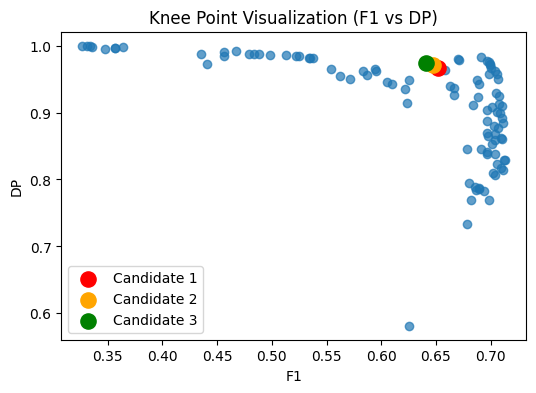

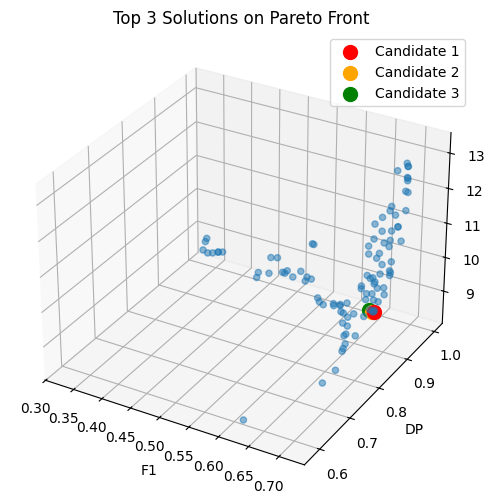

In [43]:
# STEP 4 — Visualize knee point (2D)
# F1 vs DP (most intuitive)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(f1, dp, alpha=0.7)

# highlight top 3
colors = ['red', 'orange', 'green']
for i, idx in enumerate(top3_idx):
    plt.scatter(f1[idx], dp[idx], color=colors[i], s=120, label=f"Candidate {i+1}")

plt.xlabel("F1")
plt.ylabel("DP")
plt.title("Knee Point Visualization (F1 vs DP)")
plt.legend()
plt.show()

# STEP 5 — Visualize in 3D (with highlights)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(f1, dp, comp, alpha=0.5)

for i, idx in enumerate(top3_idx):
    ax.scatter(
        f1[idx],
        dp[idx],
        comp[idx],
        color=colors[i],
        s=100,
        label=f"Candidate {i+1}"
    )

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")
ax.set_title("Top 3 Solutions on Pareto Front")

ax.legend()
plt.show()

In [44]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

nds = NonDominatedSorting().do(F, only_non_dominated_front=True)

print(len(nds), len(F))

13 100


In [45]:
# STEP 0 — Extract TRUE Pareto Front

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
import numpy as np

# Get indices of non-dominated points
nds = NonDominatedSorting().do(F, only_non_dominated_front=True)

# Extract Pareto front
F_pareto = F[nds]
X_pareto = X_res[nds]

f1_p = F_pareto[:, 0]
dp_p = F_pareto[:, 1]
comp_p = F_pareto[:, 2]

print("Pareto points:", len(f1_p))

Pareto points: 13


In [46]:
print("Original f1 range:", f1.min(), f1.max())
print("Pareto f1 range:", f1_p.min(), f1_p.max())

Original f1 range: 0.32683533803401077 0.7132007776878989
Pareto f1 range: 0.32683533803401077 0.6251858065953058


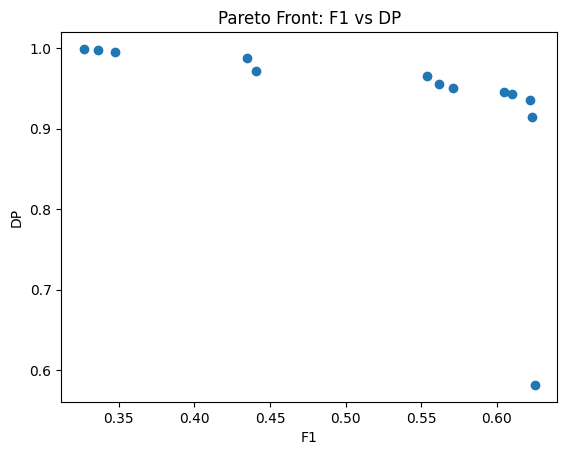

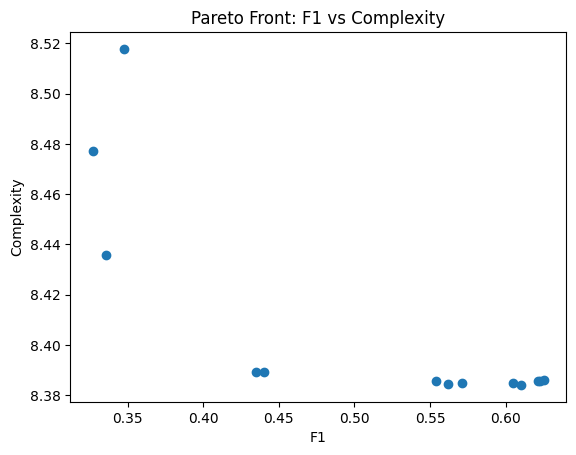

In [47]:
# STEP 1 — Plot Trade-offs (Pareto ONLY)

import matplotlib.pyplot as plt

plt.scatter(f1_p, dp_p)
plt.xlabel("F1")
plt.ylabel("DP")
plt.title("Pareto Front: F1 vs DP")
plt.show()

plt.scatter(f1_p, comp_p)
plt.xlabel("F1")
plt.ylabel("Complexity")
plt.title("Pareto Front: F1 vs Complexity")
plt.show()

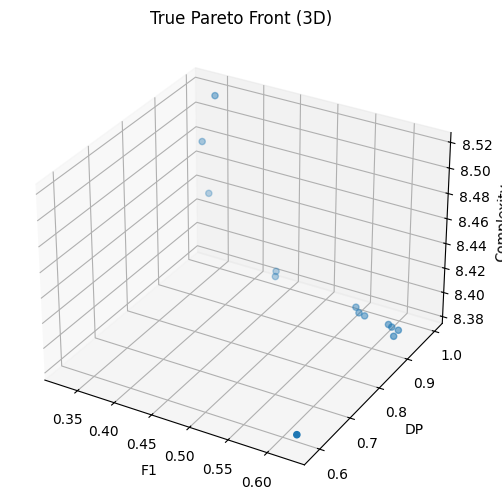

In [48]:
# STEP 2 — 3D Pareto Plot

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(f1_p, dp_p, comp_p)

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

ax.set_title("True Pareto Front (3D)")

plt.show()

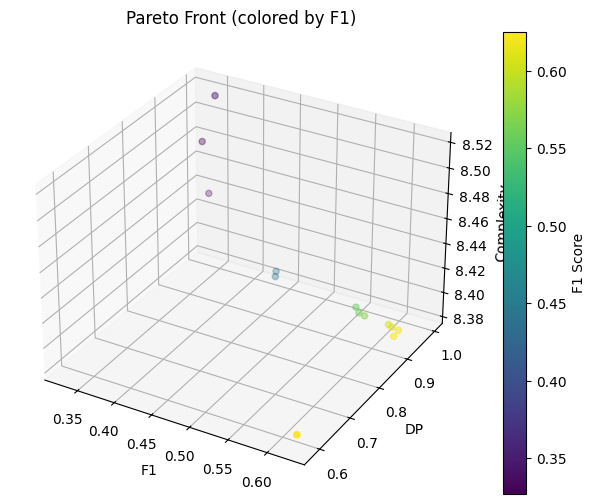

In [49]:
# STEP 3 — 3D Plot (colored by F1)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(f1_p, dp_p, comp_p, c=f1_p, cmap='viridis')

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

plt.colorbar(sc, label="F1 Score")
plt.title("Pareto Front (colored by F1)")

plt.show()

In [50]:
# STEP 4 — Normalize (Pareto ONLY)

f1_n = (f1_p - f1_p.min()) / (f1_p.max() - f1_p.min())
dp_n = (dp_p - dp_p.min()) / (dp_p.max() - dp_p.min())
comp_n = (comp_p - comp_p.min()) / (comp_p.max() - comp_p.min())

In [51]:
# STEP 5 — Knee Point (Pareto ONLY)

points = np.vstack([f1_n, dp_n, comp_n]).T
ideal = np.array([1, 1, 0])

dist = np.linalg.norm(points - ideal, axis=1)

best_idx = np.argmin(dist)

print("Best solution index:", best_idx)
print("F1:", f1_p[best_idx])
print("DP:", dp_p[best_idx])
print("Complexity:", comp_p[best_idx])

Best solution index: 1
F1: 0.6101242357347227
DP: 0.943081082586504
Complexity: 8.384115215114965


In [52]:
# STEP 6 — Top 3 Candidates (Pareto ONLY)

top3_idx = np.argsort(dist)[:3]

print("Top 3 candidate indices:", top3_idx)

for i, idx in enumerate(top3_idx):
    print(f"\nCandidate {i+1}")
    print("F1:", f1_p[idx])
    print("DP:", dp_p[idx])
    print("Complexity:", comp_p[idx])

Top 3 candidate indices: [ 1  7 11]

Candidate 1
F1: 0.6101242357347227
DP: 0.943081082586504
Complexity: 8.384115215114965

Candidate 2
F1: 0.6050374841002644
DP: 0.9449690621833353
Complexity: 8.384877019709384

Candidate 3
F1: 0.6217594519601141
DP: 0.9349295635092559
Complexity: 8.385481121798328


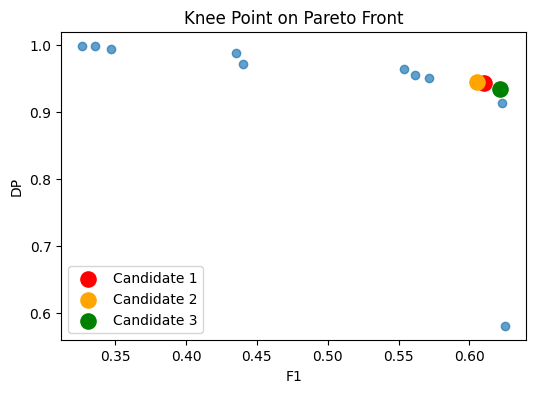

In [53]:
# STEP 7 — 2D Knee Visualization

plt.figure(figsize=(6,4))
plt.scatter(f1_p, dp_p, alpha=0.7)

colors = ['red', 'orange', 'green']
for i, idx in enumerate(top3_idx):
    plt.scatter(f1_p[idx], dp_p[idx], color=colors[i], s=120, label=f"Candidate {i+1}")

plt.xlabel("F1")
plt.ylabel("DP")
plt.title("Knee Point on Pareto Front")
plt.legend()
plt.show()

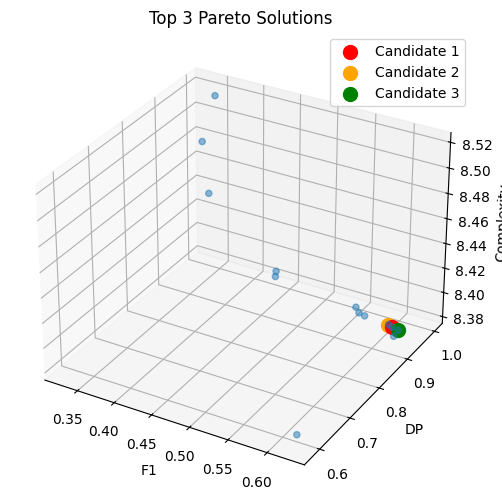

In [54]:
# STEP 8 — 3D Highlighted Pareto

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(f1_p, dp_p, comp_p, alpha=0.5)

for i, idx in enumerate(top3_idx):
    ax.scatter(
        f1_p[idx],
        dp_p[idx],
        comp_p[idx],
        color=colors[i],
        s=100,
        label=f"Candidate {i+1}"
    )

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

ax.set_title("Top 3 Pareto Solutions")

ax.legend()
plt.show()

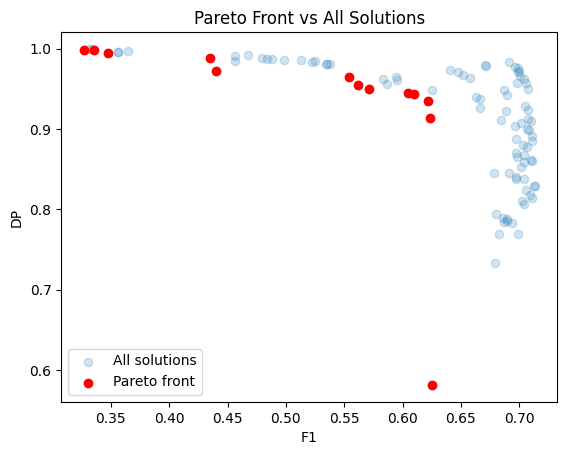

In [55]:
# STEP 9 — Overlay (All vs Pareto) [OPTIONAL but VERY USEFUL]

# Original (all solutions)
f1_all = f1
dp_all = dp

plt.scatter(f1_all, dp_all, alpha=0.2, label="All solutions")
plt.scatter(f1_p, dp_p, color='red', label="Pareto front")

plt.xlabel("F1")
plt.ylabel("DP")
plt.legend()
plt.title("Pareto Front vs All Solutions")
plt.show()

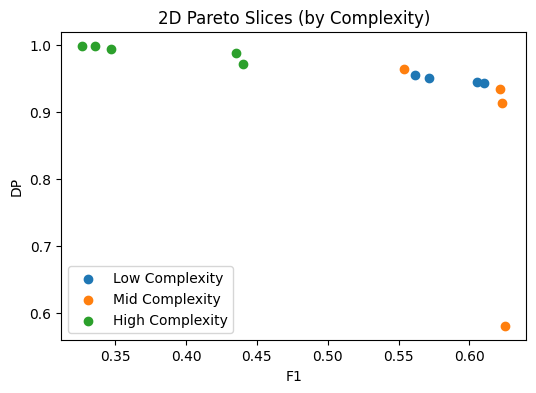

In [56]:
# 1. TRUE 2D PARETO SLICE (fix one objective)

# Define slices
low_mask = comp_p <= np.percentile(comp_p, 33)
mid_mask = (comp_p > np.percentile(comp_p, 33)) & (comp_p <= np.percentile(comp_p, 66))
high_mask = comp_p > np.percentile(comp_p, 66)

plt.figure(figsize=(6,4))

plt.scatter(f1_p[low_mask], dp_p[low_mask], label="Low Complexity")
plt.scatter(f1_p[mid_mask], dp_p[mid_mask], label="Mid Complexity")
plt.scatter(f1_p[high_mask], dp_p[high_mask], label="High Complexity")

plt.xlabel("F1")
plt.ylabel("DP")
plt.title("2D Pareto Slices (by Complexity)")
plt.legend()
plt.show()

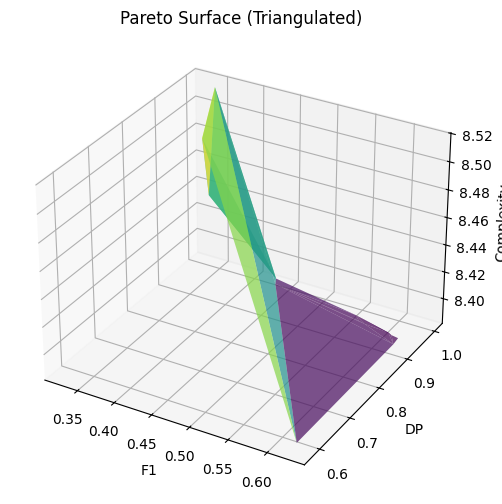

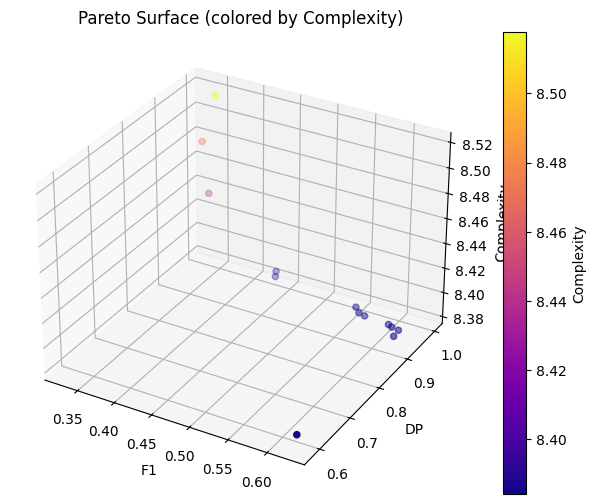

In [57]:
# 2. VISUALIZE PARETO SURFACE MORE CLEARLY

# Option A — sorted surface-like view
# sort by F1 for smoother visual
idx = np.argsort(f1_p)

f1_s = f1_p[idx]
dp_s = dp_p[idx]
comp_s = comp_p[idx]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(f1_s, dp_s, comp_s, cmap='viridis', alpha=0.7)

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")
ax.set_title("Pareto Surface (Triangulated)")

plt.show()


# Option B — color by complexity (more intuitive)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(f1_p, dp_p, comp_p, c=comp_p, cmap='plasma')

plt.colorbar(sc, label="Complexity")

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")
ax.set_title("Pareto Surface (colored by Complexity)")

plt.show()

Number of fronts: 13


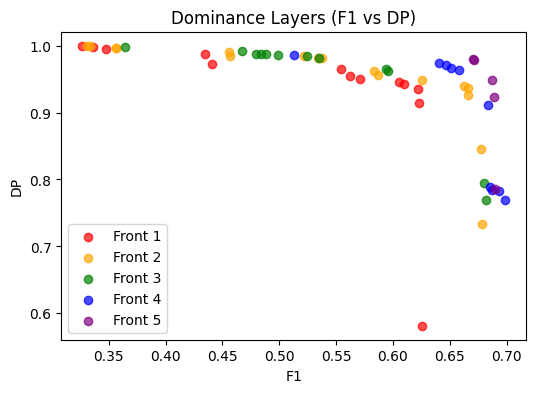

In [58]:
# 3. DOMINANCE LAYERS (VERY INSIGHTFUL)

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

nds_full = NonDominatedSorting().do(F, only_non_dominated_front=False)

print("Number of fronts:", len(nds_full))

plt.figure(figsize=(6,4))

colors = ['red', 'orange', 'green', 'blue', 'purple']

for i, front in enumerate(nds_full[:5]):
    f1_layer = f1[front]
    dp_layer = dp[front]
    
    plt.scatter(f1_layer, dp_layer, color=colors[i], label=f"Front {i+1}", alpha=0.7)

plt.xlabel("F1")
plt.ylabel("DP")
plt.title("Dominance Layers (F1 vs DP)")
plt.legend()
plt.show()

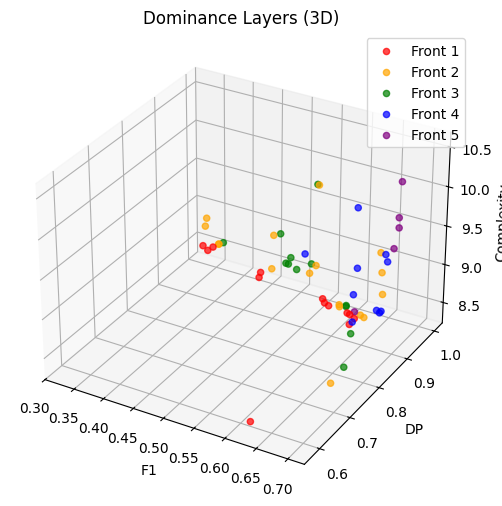

In [59]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for i, front in enumerate(nds_full[:5]):
    ax.scatter(
        f1[front],
        dp[front],
        comp[front],
        color=colors[i],
        label=f"Front {i+1}",
        alpha=0.7
    )

ax.set_xlabel("F1")
ax.set_ylabel("DP")
ax.set_zlabel("Complexity")

ax.legend()
plt.title("Dominance Layers (3D)")
plt.show()

In [66]:
from pymoo.indicators.hv import HV

F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0))

ref_point = np.array([1.1, 1.1, 1.1])  # slightly worse than normalized space

hv = HV(ref_point=ref_point)
hv_value = hv.do(F_norm)

print("Hypervolume:", hv_value)

Hypervolume: 0.5305820070990555


In [69]:
from scipy.spatial.distance import cdist

def spacing_metric(F):
    D = cdist(F, F)
    np.fill_diagonal(D, np.inf)
    
    d = np.min(D, axis=1)
    return np.std(d)

spacing = spacing_metric(F_pareto)
print("Spacing:", spacing)

Spacing: 0.08431597177815177


In [62]:
import pandas as pd

pareto_table = pd.DataFrame({
    "F1": f1_p,
    "DP": dp_p,
    "Complexity": comp_p
})

# pick top 4–6 representative points
pareto_table_sorted = pareto_table.sort_values("F1", ascending=False)

print(pareto_table_sorted.head(6))

          F1        DP  Complexity
0   0.625186  0.581568    8.386094
12  0.623123  0.914265    8.385481
11  0.621759  0.934930    8.385481
1   0.610124  0.943081    8.384115
7   0.605037  0.944969    8.384877
10  0.571287  0.950082    8.384724


In [63]:
# Example: best fairness vs best performance

best_f1_idx = np.argmax(f1_p)
best_dp_idx = np.argmax(dp_p)

print("Best F1:", f1_p[best_f1_idx], dp_p[best_f1_idx])
print("Best DP:", f1_p[best_dp_idx], dp_p[best_dp_idx])

Best F1: 0.6251858065953058 0.5815683498170455
Best DP: 0.32683533803401077 0.9989073630789358
